# Video Game Sales

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import eurostat as eu

In [83]:
df = pd.read_csv(r'C:\Users\Danish\Desktop\Data_sets\vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [85]:
pd.set_option('display.max_columns', None) # this is to display all the columns in the dataframe
pd.set_option('display.max_rows', None) # this is to display all the rows in the dataframe

In [86]:
# hide all warnings runtime
import warnings
warnings.filterwarnings('ignore')

In [87]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [88]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [89]:
df.isnull().sum().sort_values(ascending=False)

Year            271
Publisher        58
Rank              0
Name              0
Platform          0
Genre             0
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [90]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False) # this will show the percentage of null values in each column

Year            1.632727
Publisher       0.349440
Rank            0.000000
Name            0.000000
Platform        0.000000
Genre           0.000000
NA_Sales        0.000000
EU_Sales        0.000000
JP_Sales        0.000000
Other_Sales     0.000000
Global_Sales    0.000000
dtype: float64

In [91]:
# Fill missing Year with median within Platform
df['Year'] = df.groupby('Platform')['Year'].transform(lambda x: x.fillna(x.median()))



In [92]:
# Fill missing Publisher with the most common Publisher within Genre
df['Publisher'] = df.groupby('Genre')['Publisher'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

In [93]:
df.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [94]:
df['Year'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2003., 1986., 2000., 1995., 2016., 1991., 1981., 1987., 1980.,
       1983., 2020., 2017.])

In [95]:
df['Year'].value_counts()

Year
2009.0    1499
2008.0    1458
2010.0    1289
2007.0    1202
2011.0    1164
2006.0    1008
2005.0     975
2002.0     829
2003.0     800
2004.0     784
2012.0     657
2015.0     614
2014.0     583
2013.0     555
2001.0     482
1998.0     386
2000.0     349
2016.0     344
1999.0     341
1997.0     290
1996.0     263
1995.0     219
1994.0     121
1993.0      60
1982.0      53
1981.0      46
1992.0      43
1991.0      41
1986.0      21
1989.0      17
1983.0      17
1990.0      16
1987.0      16
1988.0      15
1985.0      14
1984.0      14
1980.0       9
2017.0       3
2020.0       1
Name: count, dtype: int64

In [96]:
df['Publisher'].unique()

array(['Nintendo', 'Microsoft Game Studios', 'Take-Two Interactive',
       'Sony Computer Entertainment', 'Activision', 'Ubisoft',
       'Bethesda Softworks', 'Electronic Arts', 'Sega', 'SquareSoft',
       'Atari', '505 Games', 'Capcom', 'GT Interactive',
       'Konami Digital Entertainment',
       'Sony Computer Entertainment Europe', 'Square Enix', 'LucasArts',
       'Virgin Interactive', 'Warner Bros. Interactive Entertainment',
       'Universal Interactive', 'Eidos Interactive', 'RedOctane',
       'Vivendi Games', 'Enix Corporation', 'Namco Bandai Games',
       'Palcom', 'Hasbro Interactive', 'THQ', 'Fox Interactive',
       'Acclaim Entertainment', 'MTV Games', 'Disney Interactive Studios',
       'Majesco Entertainment', 'Codemasters', 'Red Orb', 'Level 5',
       'Arena Entertainment', 'Midway Games', 'JVC', 'Deep Silver',
       '989 Studios', 'NCSoft', 'UEP Systems', 'Parker Bros.', 'Maxis',
       'Imagic', 'Tecmo Koei', 'Valve Software', 'ASCII Entertainment',
     

In [97]:
df['Publisher'].value_counts()

Publisher
Electronic Arts                           1355
Activision                                 984
Ubisoft                                    952
Namco Bandai Games                         939
Konami Digital Entertainment               832
THQ                                        715
Nintendo                                   706
Sony Computer Entertainment                683
Sega                                       639
Take-Two Interactive                       413
Capcom                                     381
Atari                                      363
Tecmo Koei                                 338
Square Enix                                233
Warner Bros. Interactive Entertainment     232
Disney Interactive Studios                 218
Unknown                                    203
Midway Games                               198
Eidos Interactive                          198
505 Games                                  192
Microsoft Game Studios                     189
D3P

In [98]:
df.duplicated().sum()

np.int64(0)

In [99]:
# let's check for number of duplicates
for col in df.columns:
    print(f"Number of duplicates in {col} column are: {df[col].duplicated().sum()}")

Number of duplicates in Rank column are: 0
Number of duplicates in Name column are: 5105
Number of duplicates in Platform column are: 16567
Number of duplicates in Year column are: 16559
Number of duplicates in Genre column are: 16586
Number of duplicates in Publisher column are: 16020
Number of duplicates in NA_Sales column are: 16189
Number of duplicates in EU_Sales column are: 16293
Number of duplicates in JP_Sales column are: 16354
Number of duplicates in Other_Sales column are: 16441
Number of duplicates in Global_Sales column are: 15975


In [100]:
# find exact duplicates and print them

# df[df['Rank'].duplicated(keep=False)].sort_values(by='Rank')

In [101]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.395891,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.849829,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [102]:
# Give me the unique values of each column by busing loop
for col in df.columns:
 print(f"Number of unique valuess in {col} column are: {df[col].unique()}")


Number of unique valuess in Rank column are: [    1     2     3 ... 16598 16599 16600]
Number of unique valuess in Name column are: ['Wii Sports' 'Super Mario Bros.' 'Mario Kart Wii' ... 'Plushees'
 'Woody Woodpecker in Crazy Castle 5' 'Know How 2']
Number of unique valuess in Platform column are: ['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
Number of unique valuess in Year column are: [2006. 1985. 2008. 2009. 1996. 1989. 1984. 2005. 1999. 2007. 2010. 2013.
 2004. 1990. 1988. 2002. 2001. 2011. 1998. 2015. 2012. 2014. 1992. 1997.
 1993. 1994. 1982. 2003. 1986. 2000. 1995. 2016. 1991. 1981. 1987. 1980.
 1983. 2020. 2017.]
Number of unique valuess in Genre column are: ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
Number of unique valuess in Publisher column are: ['Nin

In [103]:
# Create new features
df['Total_Sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']
df['NA_Sales_Share'] = df['NA_Sales'] / df['Global_Sales']


In [104]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Total_Sales,NA_Sales_Share
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,0.501450
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,0.722664
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,0.442490
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,0.477273
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,0.359260


<Axes: xlabel='Genre'>

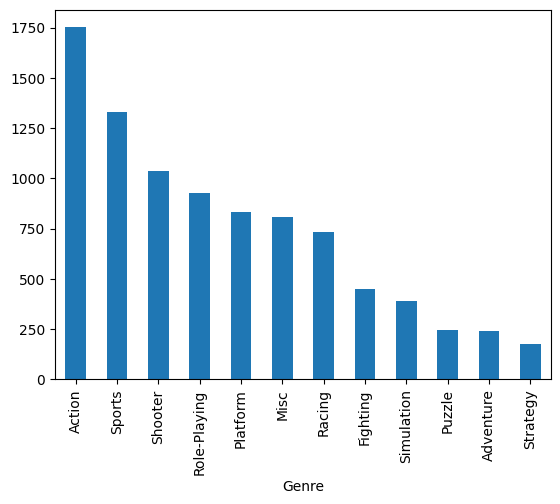

In [105]:
df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).plot(kind='bar')


<Axes: xlabel='Year'>

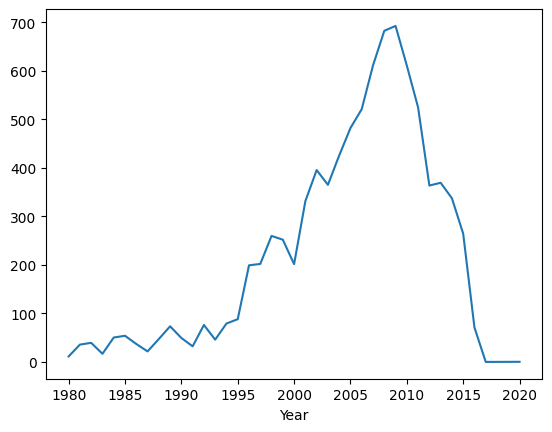

In [106]:
df.groupby('Year')['Global_Sales'].sum().plot(kind='line')


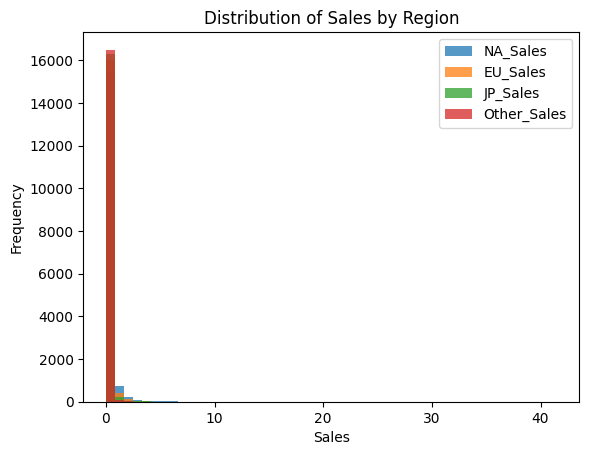

In [107]:


# Plot distribution of sales by region
df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].plot(kind='hist', bins=50, alpha=0.75)
plt.title("Distribution of Sales by Region")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.legend(['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])
plt.show()


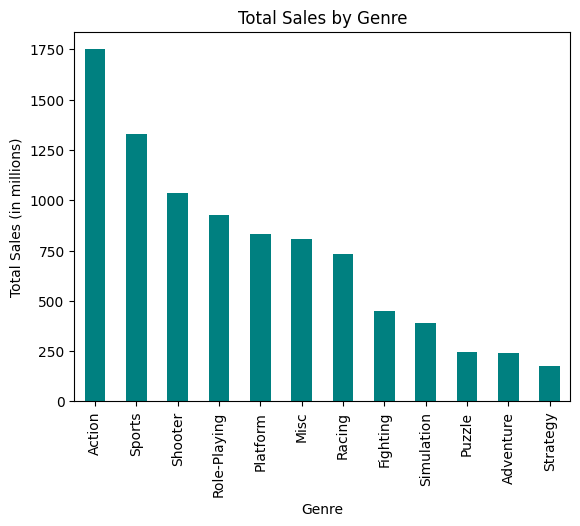

In [108]:

# Calculate total sales by genre
genre_sales = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
genre_sales['Total_Sales'] = genre_sales.sum(axis=1)

# Plot total sales by genre
genre_sales['Total_Sales'].sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title("Total Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Sales (in millions)")
plt.show()


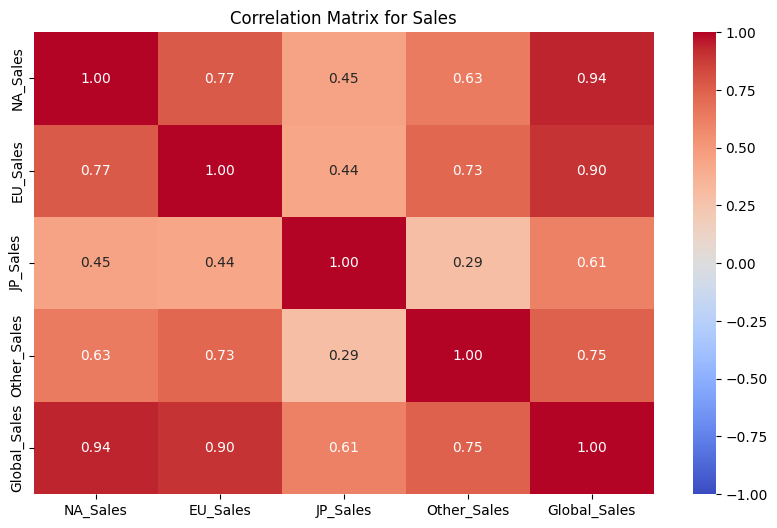

In [109]:

# Calculate correlation matrix
corr_matrix = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title("Correlation Matrix for Sales")
plt.show()


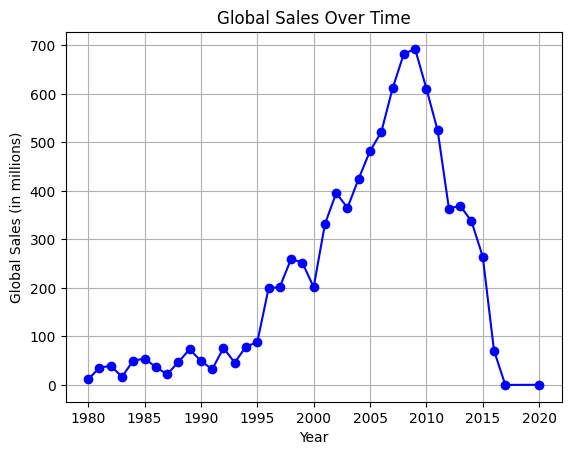

In [110]:
# Group by Year and sum the sales
yearly_sales = df.groupby('Year')['Global_Sales'].sum()

# Plot sales over time
yearly_sales.plot(kind='line', marker='o', color='b')
plt.title("Global Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Global Sales (in millions)")
plt.grid(True)
plt.show()


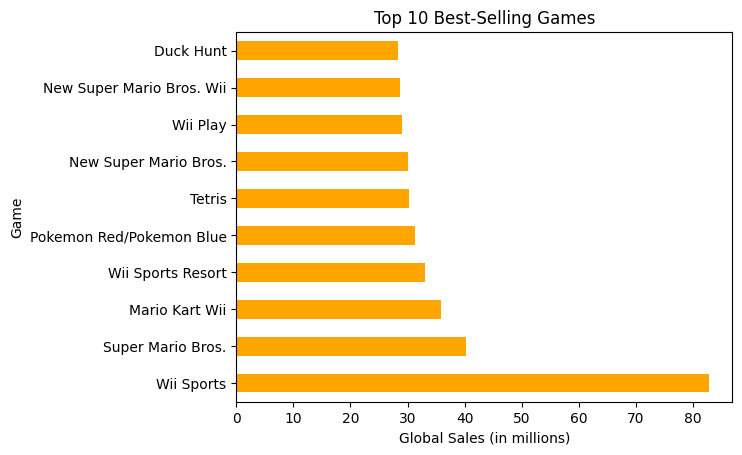

In [111]:
# Sort by Global Sales and get top 10 games
top_10_games = df[['Name', 'Global_Sales']].sort_values(by='Global_Sales', ascending=False).head(10)

# Plot top 10 best-selling games
top_10_games.plot(kind='barh', x='Name', y='Global_Sales', color='orange', legend=False)
plt.title("Top 10 Best-Selling Games")
plt.xlabel("Global Sales (in millions)")
plt.ylabel("Game")
plt.show()


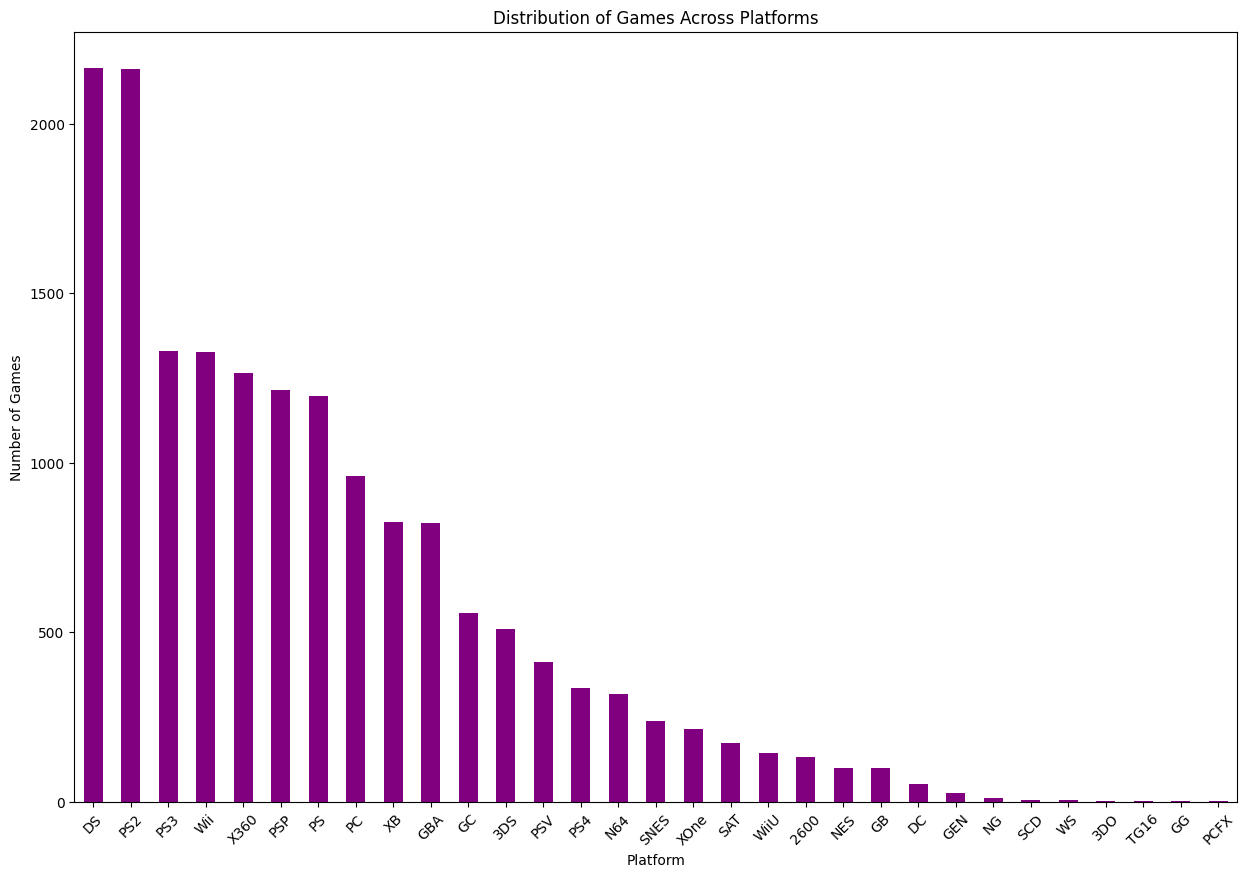

In [112]:
# Count games by platform
platform_counts = df['Platform'].value_counts()

# Plot distribution of games by platform
plt.figure(figsize=(15, 10))
platform_counts.plot(kind='bar', color='purple')
plt.title("Distribution of Games Across Platforms")
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.show()


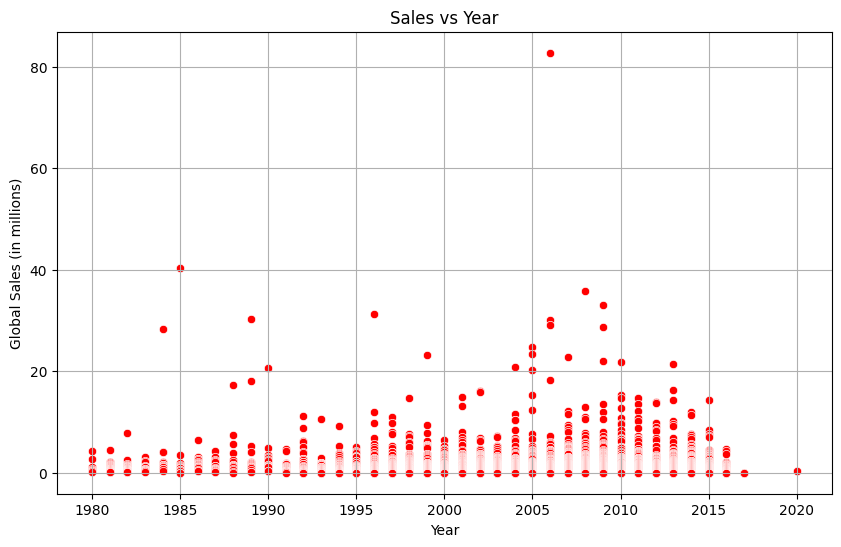

In [113]:
# Scatter plot of Year vs Global Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year', y='Global_Sales', data=df, color='r')
plt.title("Sales vs Year")
plt.xlabel("Year")
plt.ylabel("Global Sales (in millions)")
plt.grid(True)
plt.show()


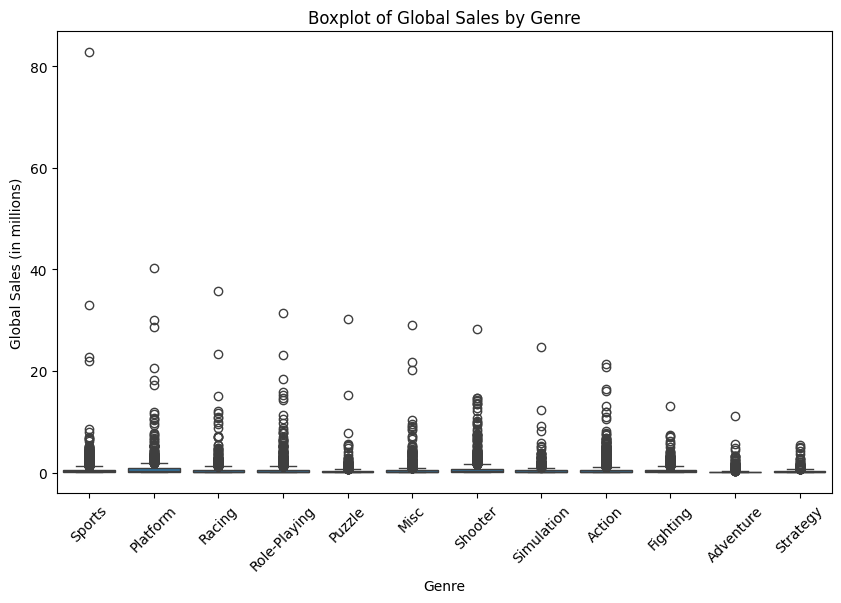

In [114]:
# Boxplot of Global Sales by Genre
plt.figure(figsize=(10, 6))
sns.boxplot(x='Genre', y='Global_Sales', data=df)
plt.title("Boxplot of Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Global Sales (in millions)")
plt.xticks(rotation=45)
plt.show()


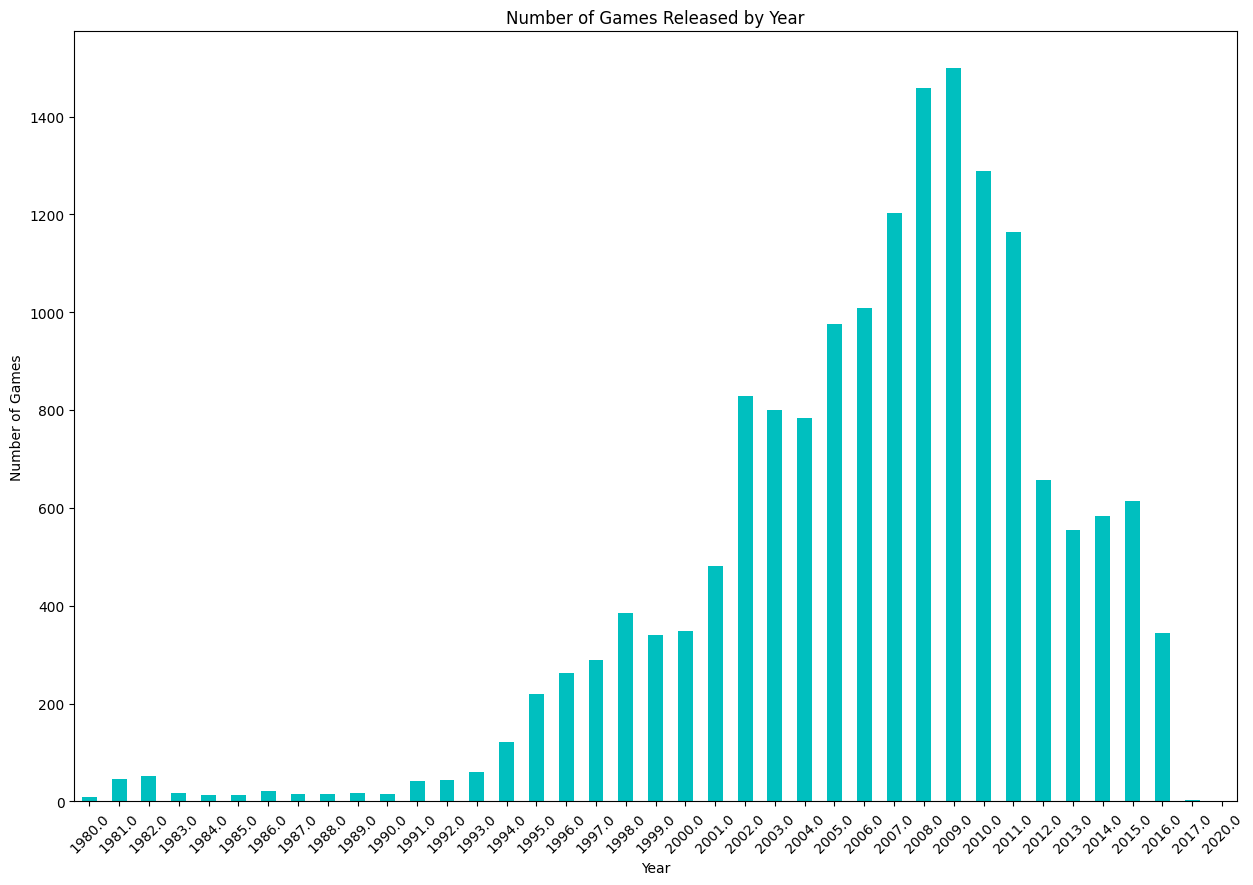

In [115]:
# Count the number of games released by year
games_by_year = df['Year'].value_counts().sort_index()

# Plot games released by year
plt.figure(figsize=(15, 10))
games_by_year.plot(kind='bar', color='c')
plt.title("Number of Games Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.show()

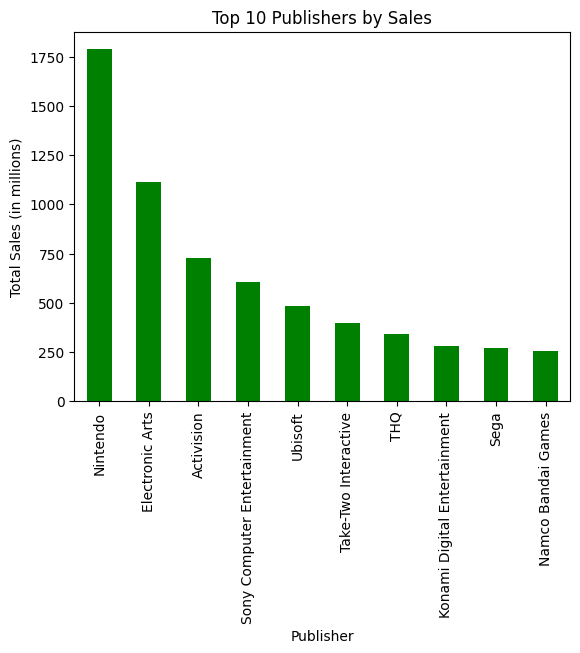

In [116]:
# Aggregate sales by Publisher
publisher_sales = df.groupby('Publisher')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

# Sort publishers by total sales and plot
publisher_sales['Total_Sales'] = publisher_sales.sum(axis=1)
publisher_sales['Total_Sales'].sort_values(ascending=False).head(10).plot(kind='bar', color='green')
plt.title("Top 10 Publishers by Sales")
plt.xlabel("Publisher")
plt.ylabel("Total Sales (in millions)")
plt.show()


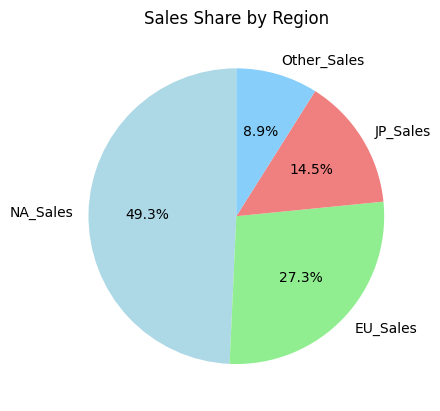

In [117]:
# Calculate total sales by region
region_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

# Plot pie chart of sales share by region
region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral', 'lightskyblue'])
plt.title("Sales Share by Region")
plt.ylabel('')
plt.show()
